In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [ ]:
df=pd.read_csv(r"C:\ProgramData\MySQL\MySQL Server 8.0\Uploads\P_Accident.csv")
print(df)

In [4]:
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Street,City,District,...,Temperature(F),Humidity(%),Visibility(mi),Wind_Speed(mph),Weather_Condition,Crossing,Junction,Stop,Traffic_Signal,Sunrise_Sunset
0,A-7152497,3,2020-04-03- 06:13:59,2020-04-20 06:48:57,40.001870,-76.617170,0.000,W Market St,York,York,...,47.0,39,10.0,13.0,Partly Cloudy,0,0,0,0,Night
1,A-1426795,3,2020-08-17- 15:25:45,2020-08-20 16:10:23,33.412769,-84.162422,0.000,GA-401 N,McDonough,Henry,...,86.0,58,10.0,6.0,Mostly Cloudy,0,0,0,0,Day
2,A-816724,2,2021-11-16- 08:02:39,2021-11-21 09:00:00,35.315788,-80.713364,0.000,Pavilion Blvd,Charlotte,Mecklenburg,...,36.0,93,10.0,0.0,Fair,0,0,0,0,Day
3,A-6174994,2,2021-08-30- 20:04:12,2021-08-21 21:24:33,35.008077,-81.144434,0.445,Harper Rd,York,York,...,81.0,72,10.0,7.0,Fair,0,0,0,0,Night
4,A-2044954,2,2019-06-11- 08:04:53,2019-06-19 09:04:28,33.742149,-84.408150,0.000,Whitehall St SW,Atlanta,Fulton,...,66.0,75,10.0,5.0,Fair,1,0,0,1,Day


In [6]:
df.columns

Index(['ID', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'Street', 'City', 'District', 'State', 'Temperature(F)',
       'Humidity(%)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Weather_Condition',
       'Crossing', 'Junction', 'Stop', 'Traffic_Signal', 'Sunrise_Sunset'],
      dtype='object')

In [6]:
df['Start_Time'] = pd.to_datetime(df['Start_Time'])
df['End_Time']=pd.to_datetime(df['End_Time'])

In [15]:
df.head()

,ID,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,Distance(mi),Street,City,District,...,Humidity(%),Visibility(mi),Wind_Speed(mph),Weather_Condition,Crossing,Junction,Stop,Traffic_Signal,Sunrise_Sunset,Hour
0,A-7152497,3,2020-04-03 06:13:59,2020-04-20 06:48:57,40.001870,-76.617170,0.000,W Market St,York,York,...,39,10.0,13.0,Partly Cloudy,0,0,0,0,Night,6
1,A-1426795,3,2020-08-17 15:25:45,2020-08-20 16:10:23,33.412769,-84.162422,0.000,GA-401 N,McDonough,Henry,...,58,10.0,6.0,Mostly Cloudy,0,0,0,0,Day,15
2,A-816724,2,2021-11-16 08:02:39,2021-11-21 09:00:00,35.315788,-80.713364,0.000,Pavilion Blvd,Charlotte,Mecklenburg,...,93,10.0,0.0,Fair,0,0,0,0,Day,8
3,A-6174994,2,2021-08-30 20:04:12,2021-08-21 21:24:33,35.008077,-81.144434,0.445,Harper Rd,York,York,...,72,10.0,7.0,Fair,0,0,0,0,Night,20
4,A-2044954,2,2019-06-11 08:04:53,2019-06-19 09:04:28,33.742149,-84.408150,0.000,Whitehall St SW,Atlanta,Fulton,...,75,10.0,5.0,Fair,1,0,0,1,Day,8


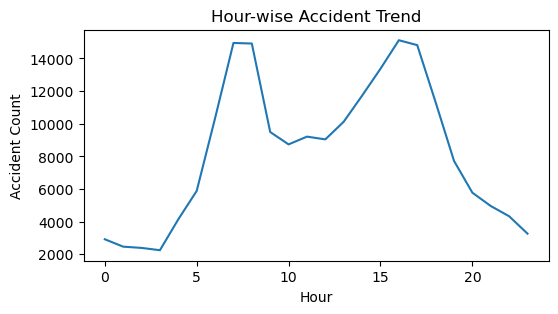

In [35]:
df['Hour']= df['Start_Time'].dt.hour
hourly_accidents = df.groupby('Hour')['ID'].count()
plt.figure(figsize=(6,3))
hourly_accidents.plot(kind='line')

plt.xlabel("Hour")
plt.ylabel("Accident Count")
plt.title("Hour-wise Accident Trend")
plt.show()


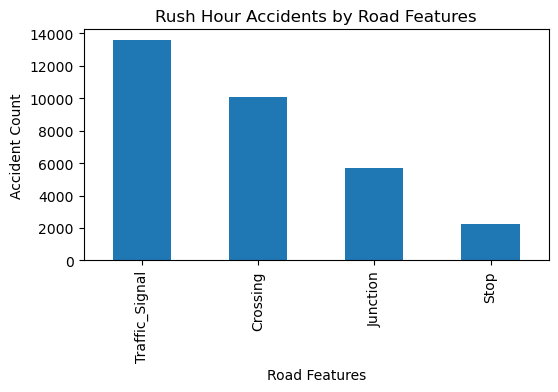

In [33]:
rush_hour_df = df[((df['Hour'] >= 7) & (df['Hour'] <= 9)) |
((df['Hour'] >= 16) & (df['Hour'] <= 18))]
road_features = ['Traffic_Signal', 'Crossing','Junction', 'Stop']
feature_counts = rush_hour_df[road_features].sum()
plt.figure(figsize=(6,3))
feature_counts.plot(kind='bar')

plt.xlabel("Road Features")
plt.ylabel("Accident Count")
plt.title("Rush Hour Accidents by Road Features")
plt.show()

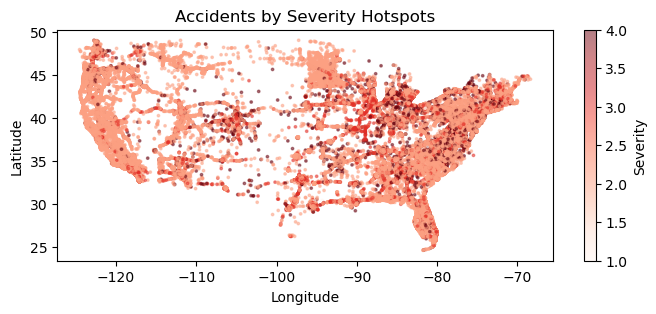

In [44]:
plt.figure(figsize=(8,3))
plt.scatter(df["Start_Lng"], df["Start_Lat"],c=df['Severity'], cmap="Reds",
s=3,alpha=0.5)
plt.title('Accidents by Severity Hotspots')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.colorbar(label="Severity")
plt.show()

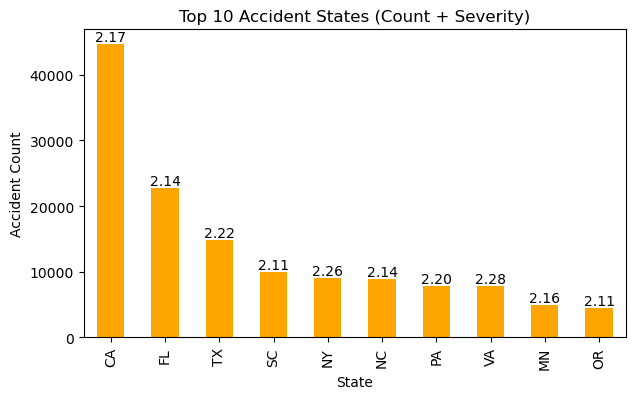

In [58]:
top_states = df.groupby("State")["ID"].count().sort_values(ascending=False).head(10)
avg_severity = df.groupby("State")["Severity"].mean().loc[top_states.index]
plt.figure(figsize=(7,4))
top_states.plot(kind="bar", color="orange")
plt.title("Top 10 Accident States (Count + Severity)")
plt.xlabel("State")
plt.ylabel("Accident Count")
for i, v in enumerate(top_states):
    plt.text(i, v, f"{avg_severity.iloc[i]:.2f}", ha='center', va='bottom')
plt.show()

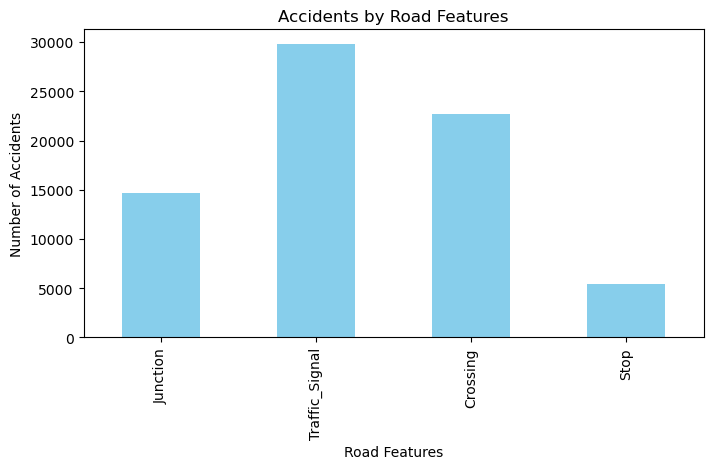

In [59]:
road_cols = ["Junction", "Traffic_Signal", "Crossing", "Stop"]
road_count = df[road_cols].sum()
plt.figure(figsize=(8,4))
road_count.plot(kind="bar", color="skyblue")
plt.title("Accidents by Road Features")
plt.xlabel("Road Features")
plt.ylabel("Number of Accidents")
plt.show()